In [ ]:
import os

# Create the model package directory structure
os.makedirs('model', exist_ok=True)
with open('model/__init__.py', 'w') as f:
    pass

# Write poly.py
with open('model/poly.py', 'w') as f:
    f.write('''
import numpy as np

class Poly:
    def __init__(self, n):
        self.n = n
        self.Q = np.zeros((n, n))
        self.offset = 0.0

    def add(self, other, weight=1.0):
        self.Q += weight * other.Q
        self.offset += weight * other.offset
        return self

def add_linear(poly, i, coef, weight=1.0):
    poly.Q[i, i] += weight * coef

def add_product(poly, i, j, coef, weight=1.0):
    if i == j:
        poly.Q[i, i] += weight * coef
    else:
        lo, hi = (i, j) if i < j else (j, i)
        poly.Q[lo, hi] += weight * coef

def add_square(poly, terms, const, weight=1.0):
    items = list(terms.items())
    poly.offset += weight * const ** 2
    for a, (i, ci) in enumerate(items):
        poly.Q[i, i] += weight * (ci * ci + 2.0 * ci * const)
        for j, cj in items[a + 1:]:
            add_product(poly, i, j, 2.0 * ci * cj, weight)
''')

# Write variables.py
with open('model/variables.py', 'w') as f:
    f.write('''
import copy
import math
import numpy as np

_MASTER = dict(
    price=[0.12, 0.30, 0.18],
    base_load=[20.0, 35.0, 25.0],
    v2g_revenue=[0.10, 0.35, 0.20],
    depot_cost=[[2.0, 3.5], [3.0, 1.5]],
)

def _make(name, n_ev, n_slots, n_depots, k, blocked=None, v2g=False, C=60.0, slack=False, A=1.5):
    return dict(
        name=name,
        n_ev=n_ev, n_slots=n_slots, n_depots=n_depots,
        p=10.0,
        dt=1.0,
        price=_MASTER["price"][:n_slots],
        base_load=_MASTER["base_load"][:n_slots],
        v2g_revenue=_MASTER["v2g_revenue"][:n_slots],
        depot_cost=[row[:n_depots] for row in _MASTER["depot_cost"][:n_ev]],
        k=k,
        blocked={int(i): list(v) for i, v in (blocked or {}).items()},
        C=C,
        capacity=60.0,
        soc_start=[30.0] * n_ev,
        soc_min=5.0,
        v2g=v2g,
        transformer_slack=slack,
        weights=dict(energy=1.0, peak=1.0, depot=1.0, v2g=1.0),
        A=A,
    )

CONFIGS = {
    "4var":  _make("4var", 1, 2, 2, k=[1]),
    "8var":  _make("8var", 2, 2, 2, k=[1, 1], blocked={1: [1]}),
    "10var": _make("10var", 2, 3, 2, k=[2, 1], blocked={1: [2]}),
    "11var_slack": _make("11var_slack", 2, 3, 2, k=[2, 1], blocked={1: [2]}, C=45.0, slack=True),
    "16var_v2g": _make("16var_v2g", 2, 3, 2, k=[1, 1], blocked={1: [2]}, v2g=True),
}
INSTANCE_ORDER = ["4var", "8var", "10var", "11var_slack", "16var_v2g"]

def get_config(name="10var"):
    return copy.deepcopy(CONFIGS[name])

def headroom(config, t):
    return math.floor((config["C"] - config["base_load"][t]) / config["p"] + 1e-9)

def slack_sizes(config):
    if not config["transformer_slack"]:
        return {}
    off = config["n_ev"] if config["v2g"] else 0
    out = {}
    for t in range(config["n_slots"]):
        H = headroom(config, t)
        if H < 0:
            raise ValueError(f"Slot {t}: base load already exceeds transformer limit")
        if H < config["n_ev"]:
            out[t] = H + off
    return out

def build_index_map(config):
    idx, n = {}, 0
    for i in range(config["n_ev"]):
        for t in range(config["n_slots"]):
            idx[("x", i, t)] = n; n += 1
    for i in range(config["n_ev"]):
        for d in range(config["n_depots"]):
            idx[("a", i, d)] = n; n += 1
    if config["v2g"]:
        for i in range(config["n_ev"]):
            for t in range(config["n_slots"]):
                idx[("g", i, t)] = n; n += 1
    for t, S in slack_sizes(config).items():
        for m in range(S):
            idx[("s", t, m)] = n; n += 1
    return idx

def as_bits(bitstring):
    if isinstance(bitstring, str):
        return np.array([int(c) for c in bitstring], dtype=int)
    return np.asarray(bitstring).astype(int).ravel()

def to_str(bits):
    return "".join(str(int(b)) for b in as_bits(bits))

def bits_from_dict(config, idx, charge=(), depot=(), discharge=(), slack=()):
    b = np.zeros(len(idx), dtype=int)
    for i, t in charge:
        b[idx[("x", i, t)]] = 1
    for i, d in depot:
        b[idx[("a", i, d)]] = 1
    for i, t in discharge:
        b[idx[("g", i, t)]] = 1
    for t, m in slack:
        b[idx[("s", t, m)]] = 1
    return b

def soc_trace(bits, config, idx):
    bits = as_bits(bits)
    e = config["p"] * config["dt"]
    trace = []
    for i in range(config["n_ev"]):
        soc, row = config["soc_start"][i], []
        for t in range(config["n_slots"]):
            soc += e * bits[idx[("x", i, t)]]
            if config["v2g"]:
                soc -= e * bits[idx[("g", i, t)]]
            row.append(soc)
        trace.append(row)
    return trace

def decode_bits(bitstring, idx):
    bits = as_bits(bitstring)
    n_ev = 1 + max(k[1] for k in idx if k[0] in ("x", "a", "g"))
    sched = dict(charge={i: [] for i in range(n_ev)},
                 discharge={i: [] for i in range(n_ev)},
                 depot={i: [] for i in range(n_ev)})
    for key, pos in idx.items():
        if not bits[pos]:
            continue
        kind, a, b = key
        if kind == "x":
            sched["charge"][a].append(b)
        elif kind == "g":
            sched["discharge"][a].append(b)
        elif kind == "a":
            sched["depot"][a].append(b)
    for part in sched.values():
        for v in part.values():
            v.sort()
    return sched

def describe(bitstring, idx):
    sched = decode_bits(bitstring, idx)
    has_g = any(k[0] == "g" for k in idx)
    lines = []
    for i in sorted(sched["charge"]):
        ch = ", ".join(map(str, sched["charge"][i])) or "none"
        dep = "+".join(chr(65 + d) for d in sched["depot"][i]) or "no depot"
        s = f"EV{i + 1}: charges in slots {ch}"
        if has_g:
            s += "; discharges in slots " + (", ".join(map(str, sched["discharge"][i])) or "none")
        lines.append(s + f"; depot {dep}" if dep != "no depot" else s + "; no depot")
    return "\n".join(lines)
''')

# Write objective.py
with open('model/objective.py', 'w') as f:
    f.write('''
from model.poly import Poly, add_linear, add_square
from model.variables import build_index_map, as_bits

def normalizers(cfg):
    p, dt, n_ev, T = cfg["p"], cfg["dt"], cfg["n_ev"], cfg["n_slots"]
    e = p * dt
    energy_max = sum(cfg["price"][t] * e * n_ev for t in range(T))
    peak_max = 0.0
    for t in range(T):
        L = cfg["base_load"][t]
        cands = [(L + p * n_ev) ** 2]
        if cfg["v2g"]:
            cands.append((L - p * n_ev) ** 2)
        peak_max += max(cands)
    depot_max = sum(max(row) for row in cfg["depot_cost"])
    v2g_max = sum(cfg["v2g_revenue"][t] * e * n_ev for t in range(T)) if cfg["v2g"] else 1.0
    return dict(energy=energy_max or 1.0, peak=peak_max or 1.0,
                depot=depot_max or 1.0, v2g=v2g_max or 1.0)

def build_objective(cfg, idx=None):
    idx = idx or build_index_map(cfg)
    poly = Poly(len(idx))
    N, W = normalizers(cfg), cfg["weights"]
    e = cfg["p"] * cfg["dt"]
    for i in range(cfg["n_ev"]):
        for t in range(cfg["n_slots"]):
            add_linear(poly, idx[("x", i, t)], cfg["price"][t] * e, W["energy"] / N["energy"])
            if cfg["v2g"]:
                add_linear(poly, idx[("g", i, t)], -cfg["v2g_revenue"][t] * e, W["v2g"] / N["v2g"])
        for d in range(cfg["n_depots"]):
            add_linear(poly, idx[("a", i, d)], cfg["depot_cost"][i][d], W["depot"] / N["depot"])
    for t in range(cfg["n_slots"]):
        terms = {idx[("x", i, t)]: cfg["p"] for i in range(cfg["n_ev"])}
        if cfg["v2g"]:
            terms.update({idx[("g", i, t)]: -cfg["p"] for i in range(cfg["n_ev"])})
        add_square(poly, terms, cfg["base_load"][t], W["peak"] / N["peak"])
    return poly

def objective_terms(bits, cfg, idx=None):
    idx = idx or build_index_map(cfg)
    b = as_bits(bits)
    N, W = normalizers(cfg), cfg["weights"]
    e = cfg["p"] * cfg["dt"]
    energy = depot = v2g = peak = 0.0
    for i in range(cfg["n_ev"]):
        for t in range(cfg["n_slots"]):
            energy += cfg["price"][t] * e * b[idx[("x", i, t)]]
            if cfg["v2g"]:
                v2g -= cfg["v2g_revenue"][t] * e * b[idx[("g", i, t)]]
        for d in range(cfg["n_depots"]):
            depot += cfg["depot_cost"][i][d] * b[idx[("a", i, d)]]
    for t in range(cfg["n_slots"]):
        net = sum(b[idx[("x", i, t)]] for i in range(cfg["n_ev"]))
        if cfg["v2g"]:
            net -= sum(b[idx[("g", i, t)]] for i in range(cfg["n_ev"]))
        peak += (cfg["base_load"][t] + cfg["p" ] * net) ** 2
    return dict(energy=W["energy"] * energy / N["energy"],
                peak=W["peak"] * peak / N["peak"],
                depot=W["depot" ] * depot / N["depot"],
                v2g=W["v2g"] * v2g / N["v2g"])

def objective_value(bits, cfg, idx=None):
    return float(sum(objective_terms(bits, cfg, idx).values()))
''')

# Write constraints.py
with open('model/constraints.py', 'w') as f:
    f.write('''
from model.poly import Poly, add_linear, add_product, add_square
from model.variables import build_index_map, headroom, slack_sizes

def charge_count(cfg, idx):
    poly = Poly(len(idx))
    for i in range(cfg["n_ev"]):
        terms = {idx[("x", i, t)]: 1.0 for t in range(cfg["n_slots"])}
        if cfg["v2g"]:
            terms.update({idx[("g", i, t)]: -1.0 for t in range(cfg["n_slots"])})
        add_square(poly, terms, -cfg["k"][i])
    return poly

def one_depot(cfg, idx):
    poly = Poly(len(idx))
    for i in range(cfg["n_ev"]):
        add_square(poly, {idx[("a", i, d)]: 1.0 for d in range(cfg["n_depots"])}, -1.0)
    return poly

def trip_blocks(cfg, idx):
    poly = Poly(len(idx))
    for i, slots in cfg["blocked"].items():
        for t in slots:
            add_linear(poly, idx[("x", i, t)], 1.0)
            if cfg["v2g"]:
                add_linear(poly, idx[("g", i, t)], 1.0)
    return poly

def no_simultaneous(cfg, idx):
    poly = Poly(len(idx))
    if cfg["v2g"]:
        for i in range(cfg["n_ev"]):
            for t in range(cfg["n_slots"]):
                add_product(poly, idx[("x", i, t)], idx[("g", i, t)], 1.0)
    return poly

def transformer(cfg, idx):
    poly = Poly(len(idx))
    for t, S in slack_sizes(cfg).items():
        terms = {idx[("x", i, t)]: 1.0 for i in range(cfg["n_ev"])}
        if cfg["v2g"]:
            terms.update({idx[("g", i, t)]: -1.0 for i in range(cfg["n_ev"])})
        terms.update({idx[("s", t, m)]: 1.0 for m in range(S)})
        add_square(poly, terms, -headroom(cfg, t))
    return poly

CONSTRAINTS = {
    "charge_count": charge_count,
    "one_depot": one_depot,
    "trip_blocks": trip_blocks,
    "no_simultaneous": no_simultaneous,
    "transformer": transformer,
}

def build_constraint_poly(cfg, idx=None, enabled=None):
    idx = idx or build_index_map(cfg)
    poly = Poly(len(idx))
    for name in (enabled or CONSTRAINTS):
        poly.add(CONSTRAINTS[name](cfg, idx))
    return poly
''')

# Write qubo.py
with open('model/qubo.py', 'w') as f:
    f.write('''
import numpy as np
from model.variables import (build_index_map, as_bits, decode_bits, describe,
                             headroom, slack_sizes, soc_trace)
from model.objective import build_objective
from model.constraints import build_constraint_poly

def build_parts(config, enabled=None):
    idx = build_index_map(config)
    return build_objective(config, idx), build_constraint_poly(config, idx, enabled), idx

def build_qubo(config, penalty=None, enabled=None):
    A = config["A"] if penalty is None else penalty
    Po, Pc, idx = build_parts(config, enabled)
    Q = Po.Q + A * Pc.Q
    offset = Po.offset + A * Pc.offset
    return Q, offset, idx

def decode(bitstring, index_map):
    return decode_bits(bitstring, index_map)

def qubo_energy(bitstring, Q, offset):
    x = as_bits(bitstring)
    return float(x @ Q @ x + offset)

def is_feasible(bitstring, config, idx=None):
    idx = idx or build_index_map(config)
    b = as_bits(bitstring)
    n_ev, T, D, v2g = config["n_ev"], config["n_slots"], config["n_depots"], config["v2g"]
    x = lambda i, t: b[idx[("x", i, t)]]
    g = lambda i, t: b[idx[("g", i, t)]] if v2g else 0
    for i in range(n_ev):
        if sum(x(i, t) - g(i, t) for t in range(T)) != config["k"][i]:
            return False
        if sum(b[idx[("a", i, d)]] for d in range(D)) != 1:
            return False
        for t in config["blocked"].get(i, []):
            if x(i, t) or g(i, t):
                return False
        for t in range(T):
            if x(i, t) and g(i, t):
                return False
    sizes = slack_sizes(config)
    for t in range(T):
        net = sum(x(i, t) - g(i, t) for i in range(n_ev))
        if config["base_load"][t] + config["p"] * net > config["C"] + 1e-9:
            return False
        if t in sizes:
            if sum(b[idx[("s", t, m)]] for m in range(sizes[t])) != headroom(config, t) - net:
                return False
    for row in soc_trace(b, config, idx):
        if min(row) < config["soc_min"] - 1e-9 or max(row) > config["capacity"] + 1e-9:
            return False
    return True

def to_dimod_bqm(Q, offset=0.0):
    import dimod
    qd = {(i, j): float(Q[i, j]) for i in range(Q.shape[0])
          for j in range(i, Q.shape[1]) if abs(Q[i, j]) > 0}
    return dimod.BinaryQuadraticModel.from_qubo(qd, offset)
''')

# Write validate_qubo.py
with open('model/validate_qubo.py', 'w') as f:
    f.write('''
import itertools
import json
import os
import sys
from functools import lru_cache
import numpy as np
from model.variables import INSTANCE_ORDER, get_config, describe, to_str
from model.objective import objective_value
from model.qubo import build_parts, is_feasible, to_dimod_bqm

TOL = 1e-9
A_GRID = [0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1, 1.5, 2, 3, 5, 10, 20, 50]

def all_states(n):
    return np.array(list(itertools.product([0, 1], repeat=n)), dtype=float)

def energies(X, Q, offset):
    return np.einsum("si,ij,sj->s", X, Q, X) + offset

@lru_cache(maxsize=None)
def enumerate_instance(name):
    cfg = get_config(name)
    Po, Pc, idx = build_parts(cfg)
    n = len(idx)
    X = all_states(n)
    obj = np.array([objective_value(x, cfg, idx) for x in X])
    feas = np.array([is_feasible(x, cfg, idx=idx) for x in X])
    return dict(
        name=name, cfg=cfg, idx=idx, n=n, X=X, obj=obj, feas=feas,
        Eo=energies(X, Po.Q, Po.offset),
        Ep=energies(X, Pc.Q, Pc.offset),
        Po=Po, Pc=Pc,
    )

def check_penalty(data, A):
    obj, feas, Eo, Ep = data["obj"], data["feas"], data["Eo"], data["Ep"]
    E = Eo + A * Ep
    true_opt = obj[feas].min()
    opt_mask = feas & (np.abs(obj - true_opt) < 1e-7)
    e_min = E.min()
    ground = E <= e_min + 1e-7
    c_expansion = bool(np.allclose(Eo, obj, atol=1e-7))
    c_pen_zero_iff_feas = bool(np.all(np.abs(Ep[feas]) < 1e-7) and np.all(Ep[~feas] > 0.5)) \
        if (~feas).any() else bool(np.all(np.abs(Ep[feas]) < 1e-7))
    c_min = bool(abs(e_min - true_opt) < 1e-7)
    c_ground = bool(np.all(opt_mask[ground]))
    gap = float(E[~feas].min() - true_opt) if (~feas).any() else float("inf")
    c_gap = gap > 1e-7
    passed = c_expansion and c_pen_zero_iff_feas and c_min and c_ground and c_gap
    return passed, dict(
        A=A, true_opt=float(true_opt), qubo_min=float(e_min), gap_to_best_infeasible=gap,
        expansion_exact=c_expansion, penalty_zero_iff_feasible=c_pen_zero_iff_feas,
        min_matches=c_min, ground_states_optimal=c_ground, no_infeasible_below=c_gap,
        n_ground=int(ground.sum()), n_feasible=int(feas.sum()), n_states=len(feas),
    )

def sweep_penalty(name, grid=A_GRID):
    data = enumerate_instance(name)
    results = [(A, check_penalty(data, A)[0]) for A in grid]
    A_min = None
    for A, ok in reversed(results):
        if ok:
            A_min = A
        else:
            break
    return results, A_min

def dimod_crosscheck(name, A=None):
    try:
        import dimod
    except ImportError:
        return None
    data = enumerate_instance(name)
    A = data["cfg"]["A"] if A is None else A
    Q = data["Po"].Q + A * data["Pc"].Q
    off = data["Po"].offset + A * data["Pc"].offset
    bqm = to_dimod_bqm(Q, off)
    ss = dimod.ExactSolver().sample(bqm)
    e_dimod = float(ss.first.energy)
    e_mine = float((data["Eo"] + A * data["Ep"]).min())
    ok_energy = abs(e_dimod - e_mine) < 1e-7
    ground_dimod = set()
    for samp, en in ss.data(["sample", "energy"]):
        if en <= e_dimod + 1e-7:
            ground_dimod.add(tuple(int(samp[j]) for j in range(data["n"])))
    E = data["Eo"] + A * data["Ep"]
    ground_mine = {tuple(int(v) for v in data["X"][s]) for s in np.where(E <= e_mine + 1e-7)[0]}
    return bool(ok_energy and ground_dimod == ground_mine)
''')

print("Model modules successfully created inside the 'model' directory.")

Model modules successfully created inside the 'model' directory.


In [ ]:
import os

# Create the model package directory structure
os.makedirs('model', exist_ok=True)
with open('model/__init__.py', 'w') as f:
    pass

# Write poly.py
with open('model/poly.py', 'w') as f:
    f.write('''
import numpy as np

class Poly:
    def __init__(self, n):
        self.n = n
        self.Q = np.zeros((n, n))
        self.offset = 0.0

    def add(self, other, weight=1.0):
        self.Q += weight * other.Q
        self.offset += weight * other.offset
        return self

def add_linear(poly, i, coef, weight=1.0):
    poly.Q[i, i] += weight * coef

def add_product(poly, i, j, coef, weight=1.0):
    if i == j:
        poly.Q[i, i] += weight * coef
    else:
        lo, hi = (i, j) if i < j else (j, i)
        poly.Q[lo, hi] += weight * coef

def add_square(poly, terms, const, weight=1.0):
    items = list(terms.items())
    poly.offset += weight * const ** 2
    for a, (i, ci) in enumerate(items):
        poly.Q[i, i] += weight * (ci * ci + 2.0 * ci * const)
        for j, cj in items[a + 1:]:
            add_product(poly, i, j, 2.0 * ci * cj, weight)
''')

# Write variables.py
with open('model/variables.py', 'w') as f:
    f.write('''
import copy
import math
import numpy as np

_MASTER = dict(
    price=[0.12, 0.30, 0.18],
    base_load=[20.0, 35.0, 25.0],
    v2g_revenue=[0.10, 0.35, 0.20],
    depot_cost=[[2.0, 3.5], [3.0, 1.5]],
)

def _make(name, n_ev, n_slots, n_depots, k, blocked=None, v2g=False, C=60.0, slack=False, A=1.5):
    return dict(
        name=name,
        n_ev=n_ev, n_slots=n_slots, n_depots=n_depots,
        p=10.0,
        dt=1.0,
        price=_MASTER["price"][:n_slots],
        base_load=_MASTER["base_load"][:n_slots],
        v2g_revenue=_MASTER["v2g_revenue"][:n_slots],
        depot_cost=[row[:n_depots] for row in _MASTER["depot_cost"][:n_ev]],
        k=k,
        blocked={int(i): list(v) for i, v in (blocked or {}).items()},
        C=C,
        capacity=60.0,
        soc_start=[30.0] * n_ev,
        soc_min=5.0,
        v2g=v2g,
        transformer_slack=slack,
        weights=dict(energy=1.0, peak=1.0, depot=1.0, v2g=1.0),
        A=A,
    )

CONFIGS = {
    "4var":  _make("4var", 1, 2, 2, k=[1]),
    "8var":  _make("8var", 2, 2, 2, k=[1, 1], blocked={1: [1]}),
    "10var": _make("10var", 2, 3, 2, k=[2, 1], blocked={1: [2]}),
    "11var_slack": _make("11var_slack", 2, 3, 2, k=[2, 1], blocked={1: [2]}, C=45.0, slack=True),
    "16var_v2g": _make("16var_v2g", 2, 3, 2, k=[1, 1], blocked={1: [2]}, v2g=True),
}
INSTANCE_ORDER = ["4var", "8var", "10var", "11var_slack", "16var_v2g"]

def get_config(name="10var"):
    return copy.deepcopy(CONFIGS[name])

def headroom(config, t):
    return math.floor((config["C"] - config["base_load"][t]) / config["p"] + 1e-9)

def slack_sizes(config):
    if not config["transformer_slack"]:
        return {}
    off = config["n_ev"] if config["v2g"] else 0
    out = {}
    for t in range(config["n_slots"]):
        H = headroom(config, t)
        if H < 0:
            raise ValueError(f"Slot {t}: base load already exceeds transformer limit")
        if H < config["n_ev"]:
            out[t] = H + off
    return out

def build_index_map(config):
    idx, n = {}, 0
    for i in range(config["n_ev"]):
        for t in range(config["n_slots"]):
            idx[("x", i, t)] = n; n += 1
    for i in range(config["n_ev"]):
        for d in range(config["n_depots"]):
            idx[("a", i, d)] = n; n += 1
    if config["v2g"]:
        for i in range(config["n_ev"]):
            for t in range(config["n_slots"]):
                idx[("g", i, t)] = n; n += 1
    for t, S in slack_sizes(config).items():
        for m in range(S):
            idx[("s", t, m)] = n; n += 1
    return idx

def as_bits(bitstring):
    if isinstance(bitstring, str):
        return np.array([int(c) for c in bitstring], dtype=int)
    return np.asarray(bitstring).astype(int).ravel()

def to_str(bits):
    return "".join(str(int(b)) for b in as_bits(bits))

def bits_from_dict(config, idx, charge=(), depot=(), discharge=(), slack=()):
    b = np.zeros(len(idx), dtype=int)
    for i, t in charge:
        b[idx[("x", i, t)]] = 1
    for i, d in depot:
        b[idx[("a", i, d)]] = 1
    for i, t in discharge:
        b[idx[("g", i, t)]] = 1
    for t, m in slack:
        b[idx[("s", t, m)]] = 1
    return b

def soc_trace(bits, config, idx):
    bits = as_bits(bits)
    e = config["p"] * config["dt"]
    trace = []
    for i in range(config["n_ev"]):
        soc, row = config["soc_start"][i], []
        for t in range(config["n_slots"]):
            soc += e * bits[idx[("x", i, t)]]
            if config["v2g"]:
                soc -= e * bits[idx[("g", i, t)]]
            row.append(soc)
        trace.append(row)
    return trace

def decode_bits(bitstring, idx):
    bits = as_bits(bitstring)
    n_ev = 1 + max(k[1] for k in idx if k[0] in ("x", "a", "g"))
    sched = dict(charge={i: [] for i in range(n_ev)},
                 discharge={i: [] for i in range(n_ev)},
                 depot={i: [] for i in range(n_ev)})
    for key, pos in idx.items():
        if not bits[pos]:
            continue
        kind, a, b = key
        if kind == "x":
            sched["charge"][a].append(b)
        elif kind == "g":
            sched["discharge"][a].append(b)
        elif kind == "a":
            sched["depot"][a].append(b)
    for part in sched.values():
        for v in part.values():
            v.sort()
    return sched

def describe(bitstring, idx):
    sched = decode_bits(bitstring, idx)
    has_g = any(k[0] == "g" for k in idx)
    lines = []
    for i in sorted(sched["charge"]):
        ch = ", ".join(map(str, sched["charge"][i])) or "none"
        dep = "+".join(chr(65 + d) for d in sched["depot"][i]) or "no depot"
        s = f"EV{i + 1}: charges in slots {ch}"
        if has_g:
            s += "; discharges in slots " + (", ".join(map(str, sched["discharge"][i])) or "none")
        lines.append(s + f"; depot {dep}" if dep != "no depot" else s + "; no depot")
    return "\\n".join(lines)
''')

# Write objective.py
with open('model/objective.py', 'w') as f:
    f.write('''
from model.poly import Poly, add_linear, add_square
from model.variables import build_index_map, as_bits

def normalizers(cfg):
    p, dt, n_ev, T = cfg["p"], cfg["dt"], cfg["n_ev"], cfg["n_slots"]
    e = p * dt
    energy_max = sum(cfg["price"][t] * e * n_ev for t in range(T))
    peak_max = 0.0
    for t in range(T):
        L = cfg["base_load"][t]
        cands = [(L + p * n_ev) ** 2]
        if cfg["v2g"]:
            cands.append((L - p * n_ev) ** 2)
        peak_max += max(cands)
    depot_max = sum(max(row) for row in cfg["depot_cost"])
    v2g_max = sum(cfg["v2g_revenue"][t] * e * n_ev for t in range(T)) if cfg["v2g"] else 1.0
    return dict(energy=energy_max or 1.0, peak=peak_max or 1.0,
                depot=depot_max or 1.0, v2g=v2g_max or 1.0)

def build_objective(cfg, idx=None):
    idx = idx or build_index_map(cfg)
    poly = Poly(len(idx))
    N, W = normalizers(cfg), cfg["weights"]
    e = cfg["p"] * cfg["dt"]
    for i in range(cfg["n_ev"]):
        for t in range(cfg["n_slots"]):
            add_linear(poly, idx[("x", i, t)], cfg["price"][t] * e, W["energy"] / N["energy"])
            if cfg["v2g"]:
                add_linear(poly, idx[("g", i, t)], -cfg["v2g_revenue"][t] * e, W["v2g"] / N["v2g"])
        for d in range(cfg["n_depots"]):
            add_linear(poly, idx[("a", i, d)], cfg["depot_cost"][i][d], W["depot"] / N["depot"])
    for t in range(cfg["n_slots"]):
        terms = {idx[("x", i, t)]: cfg["p"] for i in range(cfg["n_ev"])}
        if cfg["v2g"]:
            terms.update({idx[("g", i, t)]: -cfg["p"] for i in range(cfg["n_ev"])})
        add_square(poly, terms, cfg["base_load"][t], W["peak"] / N["peak"])
    return poly

def objective_terms(bits, cfg, idx=None):
    idx = idx or build_index_map(cfg)
    b = as_bits(bits)
    N, W = normalizers(cfg), cfg["weights"]
    e = cfg["p"] * cfg["dt"]
    energy = depot = v2g = peak = 0.0
    for i in range(cfg["n_ev"]):
        for t in range(cfg["n_slots"]):
            energy += cfg["price"][t] * e * b[idx[("x", i, t)]]
            if cfg["v2g"]:
                v2g -= cfg["v2g_revenue"][t] * e * b[idx[("g", i, t)]]
        for d in range(cfg["n_depots"]):
            depot += cfg["depot_cost"][i][d] * b[idx[("a", i, d)]]
    for t in range(cfg["n_slots"]):
        net = sum(b[idx[("x", i, t)]] for i in range(cfg["n_ev"]))
        if cfg["v2g"]:
            net -= sum(b[idx[("g", i, t)]] for i in range(cfg["n_ev"]))
        peak += (cfg["base_load"][t] + cfg["p" ] * net) ** 2
    return dict(energy=W["energy"] * energy / N["energy"],
                peak=W["peak" ] * peak / N["peak"],
                depot=W["depot" ] * depot / N["depot"],
                v2g=W["v2g"] * v2g / N["v2g"])

def objective_value(bits, cfg, idx=None):
    return float(sum(objective_terms(bits, cfg, idx).values()))
''')

# Write constraints.py
with open('model/constraints.py', 'w') as f:
    f.write('''
from model.poly import Poly, add_linear, add_product, add_square
from model.variables import build_index_map, headroom, slack_sizes

def charge_count(cfg, idx):
    poly = Poly(len(idx))
    for i in range(cfg["n_ev"]):
        terms = {idx[("x", i, t)]: 1.0 for t in range(cfg["n_slots"])}
        if cfg["v2g"]:
            terms.update({idx[("g", i, t)]: -1.0 for t in range(cfg["n_slots"])})
        add_square(poly, terms, -cfg["k"][i])
    return poly

def one_depot(cfg, idx):
    poly = Poly(len(idx))
    for i in range(cfg["n_ev"]):
        add_square(poly, {idx[("a", i, d)]: 1.0 for d in range(cfg["n_depots"])}, -1.0)
    return poly

def trip_blocks(cfg, idx):
    poly = Poly(len(idx))
    for i, slots in cfg["blocked"].items():
        for t in slots:
            add_linear(poly, idx[("x", i, t)], 1.0)
            if cfg["v2g"]:
                add_linear(poly, idx[("g", i, t)], 1.0)
    return poly

def no_simultaneous(cfg, idx):
    poly = Poly(len(idx))
    if cfg["v2g"]:
        for i in range(cfg["n_ev"]):
            for t in range(cfg["n_slots"]):
                add_product(poly, idx[("x", i, t)], idx[("g", i, t)], 1.0)
    return poly

def transformer(cfg, idx):
    poly = Poly(len(idx))
    for t, S in slack_sizes(cfg).items():
        terms = {idx[("x", i, t)]: 1.0 for i in range(cfg["n_ev"])}
        if cfg["v2g"]:
            terms.update({idx[("g", i, t)]: -1.0 for i in range(cfg["n_ev"])})
        terms.update({idx[("s", t, m)]: 1.0 for m in range(S)})
        add_square(poly, terms, -headroom(cfg, t))
    return poly

CONSTRAINTS = {
    "charge_count": charge_count,
    "one_depot": one_depot,
    "trip_blocks": trip_blocks,
    "no_simultaneous": no_simultaneous,
    "transformer": transformer,
}

def build_constraint_poly(cfg, idx=None, enabled=None):
    idx = idx or build_index_map(cfg)
    poly = Poly(len(idx))
    for name in (enabled or CONSTRAINTS):
        poly.add(CONSTRAINTS[name](cfg, idx))
    return poly
''')

# Write qubo.py
with open('model/qubo.py', 'w') as f:
    f.write('''
import numpy as np
from model.variables import (build_index_map, as_bits, decode_bits, describe,
                             headroom, slack_sizes, soc_trace)
from model.objective import build_objective
from model.constraints import build_constraint_poly

def build_parts(config, enabled=None):
    idx = build_index_map(config)
    return build_objective(config, idx), build_constraint_poly(config, idx, enabled), idx

def build_qubo(config, penalty=None, enabled=None):
    A = config["A"] if penalty is None else penalty
    Po, Pc, idx = build_parts(config, enabled)
    Q = Po.Q + A * Pc.Q
    offset = Po.offset + A * Pc.offset
    return Q, offset, idx

def decode(bitstring, index_map):
    return decode_bits(bitstring, index_map)

def qubo_energy(bitstring, Q, offset):
    x = as_bits(bitstring)
    return float(x @ Q @ x + offset)

def is_feasible(bitstring, config, idx=None):
    idx = idx or build_index_map(config)
    b = as_bits(bitstring)
    n_ev, T, D, v2g = config["n_ev"], config["n_slots"], config["n_depots"], config["v2g"]
    x = lambda i, t: b[idx[("x", i, t)]]
    g = lambda i, t: b[idx[("g", i, t)]] if v2g else 0
    for i in range(n_ev):
        if sum(x(i, t) - g(i, t) for t in range(T)) != config["k"][i]:
            return False
        if sum(b[idx[("a", i, d)]] for d in range(D)) != 1:
            return False
        for t in config["blocked"].get(i, []):
            if x(i, t) or g(i, t):
                return False
        for t in range(T):
            if x(i, t) and g(i, t):
                return False
    sizes = slack_sizes(config)
    for t in range(T):
        net = sum(x(i, t) - g(i, t) for i in range(n_ev))
        if config["base_load"][t] + config["p"] * net > config["C"] + 1e-9:
            return False
        if t in sizes:
            if sum(b[idx[("s", t, m)]] for m in range(sizes[t])) != headroom(config, t) - net:
                return False
    for row in soc_trace(b, config, idx):
        if min(row) < config["soc_min"] - 1e-9 or max(row) > config["capacity"] + 1e-9:
            return False
    return True

def to_dimod_bqm(Q, offset=0.0):
    import dimod
    qd = {(i, j): float(Q[i, j]) for i in range(Q.shape[0])
          for j in range(i, Q.shape[1]) if abs(Q[i, j]) > 0}
    return dimod.BinaryQuadraticModel.from_qubo(qd, offset)
''')

# Write validate_qubo.py
with open('model/validate_qubo.py', 'w') as f:
    f.write('''
import itertools
import json
import os
import sys
from functools import lru_cache
import numpy as np
from model.variables import INSTANCE_ORDER, get_config, describe, to_str
from model.objective import objective_value
from model.qubo import build_parts, is_feasible, to_dimod_bqm

TOL = 1e-9
A_GRID = [0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1, 1.5, 2, 3, 5, 10, 20, 50]

def all_states(n):
    return np.array(list(itertools.product([0, 1], repeat=n)), dtype=float)

def energies(X, Q, offset):
    return np.einsum("si,ij,sj->s", X, Q, X) + offset

@lru_cache(maxsize=None)
def enumerate_instance(name):
    cfg = get_config(name)
    Po, Pc, idx = build_parts(cfg)
    n = len(idx)
    X = all_states(n)
    obj = np.array([objective_value(x, cfg, idx) for x in X])
    feas = np.array([is_feasible(x, cfg, idx=idx) for x in X])
    return dict(
        name=name, cfg=cfg, idx=idx, n=n, X=X, obj=obj, feas=feas,
        Eo=energies(X, Po.Q, Po.offset),
        Ep=energies(X, Pc.Q, Pc.offset),
        Po=Po, Pc=Pc,
    )

def check_penalty(data, A):
    obj, feas, Eo, Ep = data["obj"], data["feas"], data["Eo"], data["Ep"]
    E = Eo + A * Ep
    true_opt = obj[feas].min()
    opt_mask = feas & (np.abs(obj - true_opt) < 1e-7)
    e_min = E.min()
    ground = E <= e_min + 1e-7
    c_expansion = bool(np.allclose(Eo, obj, atol=1e-7))
    c_pen_zero_iff_feas = bool(np.all(np.abs(Ep[feas]) < 1e-7) and np.all(Ep[~feas] > 0.5)) \
        if (~feas).any() else bool(np.all(np.abs(Ep[feas]) < 1e-7))
    c_min = bool(abs(e_min - true_opt) < 1e-7)
    c_ground = bool(np.all(opt_mask[ground]))
    gap = float(E[~feas].min() - true_opt) if (~feas).any() else float("inf")
    c_gap = gap > 1e-7
    passed = c_expansion and c_pen_zero_iff_feas and c_min and c_ground and c_gap
    return passed, dict(
        A=A, true_opt=float(true_opt), qubo_min=float(e_min), gap_to_best_infeasible=gap,
        expansion_exact=c_expansion, penalty_zero_iff_feasible=c_pen_zero_iff_feas,
        min_matches=c_min, ground_states_optimal=c_ground, no_infeasible_below=c_gap,
        n_ground=int(ground.sum()), n_feasible=int(feas.sum()), n_states=len(feas),
    )

def sweep_penalty(name, grid=A_GRID):
    data = enumerate_instance(name)
    results = [(A, check_penalty(data, A)[0]) for A in grid]
    A_min = None
    for A, ok in reversed(results):
        if ok:
            A_min = A
        else:
            break
    return results, A_min

def dimod_crosscheck(name, A=None):
    try:
        import dimod
    except ImportError:
        return None
    data = enumerate_instance(name)
    A = data["cfg"]["A"] if A is None else A
    Q = data["Po"].Q + A * data["Pc"].Q
    off = data["Po"].offset + A * data["Pc"].offset
    bqm = to_dimod_bqm(Q, off)
    ss = dimod.ExactSolver().sample(bqm)
    e_dimod = float(ss.first.energy)
    e_mine = float((data["Eo"] + A * data["Ep"]).min())
    ok_energy = abs(e_dimod - e_mine) < 1e-7
    ground_dimod = set()
    for samp, en in ss.data(["sample", "energy"]):
        if en <= e_dimod + 1e-7:
            ground_dimod.add(tuple(int(samp[j]) for j in range(data["n"])))
    E = data["Eo"] + A * data["Ep"]
    ground_mine = {tuple(int(v) for v in data["X"][s]) for s in np.where(E <= e_mine + 1e-7)[0]}
    return bool(ok_energy and ground_dimod == ground_mine)
''')

import itertools
import numpy as np
import pytest

from model.variables import (INSTANCE_ORDER, get_config, build_index_map, bits_from_dict, decode_bits, describe, soc_trace)
from model.poly import Poly, add_square
from model.objective import objective_terms, objective_value
from model.qubo import build_qubo, is_feasible, qubo_energy
from model.validate_qubo import (enumerate_instance, check_penalty, sweep_penalty,
                                 dimod_crosscheck)

EXPECTED_N = {"4var": 4, "8var": 8, "10var": 10, "11var_slack": 11, "16var_v2g": 16}

@pytest.mark.parametrize("name", INSTANCE_ORDER)
def test_variable_count(name):
    assert len(build_index_map(get_config(name))) == EXPECTED_N[name]

def test_square_expansion():
    poly = Poly(3)
    add_square(poly, {0: 1.0, 1: 1.0, 2: 1.0}, -2.0)
    for x in itertools.product([0, 1], repeat=3):
        x = np.array(x, dtype=float)
        assert x @ poly.Q @ x + poly.offset == pytest.approx((x.sum() - 2) ** 2)

def test_hand_picked_costs_and_feasibility():
    cfg = get_config("10var")
    idx = build_index_map(cfg)
    good = bits_from_dict(cfg, idx, charge=[(0, 0), (0, 2), (1, 1)], depot=[(0, 0), (1, 1)])
    assert is_feasible(good, cfg)
    bad_block = bits_from_dict(cfg, idx, charge=[(0, 0), (0, 1), (1, 2)], depot=[(0, 0), (1, 1)])
    assert not is_feasible(bad_block, cfg)
    bad_count = bits_from_dict(cfg, idx, charge=[(0, 0), (1, 1)], depot=[(0, 0), (1, 1)])
    assert not is_feasible(bad_count, cfg)
    bad_depot = bits_from_dict(cfg, idx, charge=[(0, 0), (0, 2), (1, 1)], depot=[(0, 0), (0, 1), (1, 1)])
    assert not is_feasible(bad_depot, cfg)
    e_max = (0.12 + 0.30 + 0.18) * 10 * 2
    assert objective_terms(good, cfg, idx)["energy"] == pytest.approx(6.0 / e_max)
    assert objective_terms(good, cfg, idx)["depot"] == pytest.approx(3.5 / 6.5)

def test_decode_text():
    cfg = get_config("10var")
    idx = build_index_map(cfg)
    b = bits_from_dict(cfg, idx, charge=[(0, 0), (0, 2), (1, 1)], depot=[(0, 0), (1, 1)])
    assert describe(b, idx).splitlines()[0] == "EV1: charges in slots 0, 2; depot A"
    assert decode_bits(b, idx)["depot"] == {0: [0], 1: [1]}

def test_soc_not_a_variable():
    cfg = get_config("10var")
    idx = build_index_map(cfg)
    b = bits_from_dict(cfg, idx, charge=[(0, 0), (0, 2), (1, 1)], depot=[(0, 0), (1, 1)])
    assert soc_trace(b, cfg, idx)[0] == [40.0, 40.0, 50.0]

@pytest.mark.parametrize("name", INSTANCE_ORDER)
def test_qubo_matches_brute_force(name):
    data = enumerate_instance(name)
    passed, d = check_penalty(data, data["cfg"]["A"])
    assert passed, d

@pytest.mark.parametrize("name", INSTANCE_ORDER)
def test_build_qubo_energy_equals_objective_when_feasible(name):
    cfg = get_config(name)
    Q, off, idx = build_qubo(cfg)
    data = enumerate_instance(name)
    for s in np.where(data["feas"])[0][:50]:
        assert qubo_energy(data["X"][s], Q, off) == pytest.approx(data["obj"][s])

@pytest.mark.parametrize("name", INSTANCE_ORDER)
def test_penalty_sweep_default_A_is_safe(name):
    results, A_min = sweep_penalty(name)
    assert A_min is not None
    assert get_config(name)["A"] >= A_min

def test_too_small_penalty_fails():
    assert not check_penalty(enumerate_instance("10var"), 0.05)[0]

@pytest.mark.parametrize("name", INSTANCE_ORDER)
def test_dimod_cross_check(name):
    pytest.importorskip("dimod")
    assert dimod_crosscheck(name)


In [ ]:
import sys
import pytest

# Run pytest on the generated test file. With dimod now installed, all 30 tests will run and pass.
sys.exit(pytest.main(["-v", "test_model.py"]))


============================= test session starts ==============================
platform linux -- Python 3.13.16, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content
plugins: platformdirs-4.12.2, anyio-4.15.1, typeguard-4.6.0, langsmith-0.14.2
collecting ... collected 30 items

test_model.py::test_variable_count[4var] PASSED                          [  3%]
test_model.py::test_variable_count[8var] PASSED                          [  6%]
test_model.py::test_variable_count[10var] PASSED                         [ 10%]
test_model.py::test_variable_count[11var_slack] PASSED                   [ 13%]
test_model.py::test_variable_count[16var_v2g] PASSED                     [ 16%]
test_model.py::test_square_expansion PASSED                              [ 20%]
test_model.py::test_hand_picked_costs_and_feasibility PASSED             [ 23%]
test_model.py::test_decode_text PASSED                                   [ 26%]
test_model.py::test_soc_not_a_variable PASS

SystemExit: 0

/usr/local/lib/python3.13/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


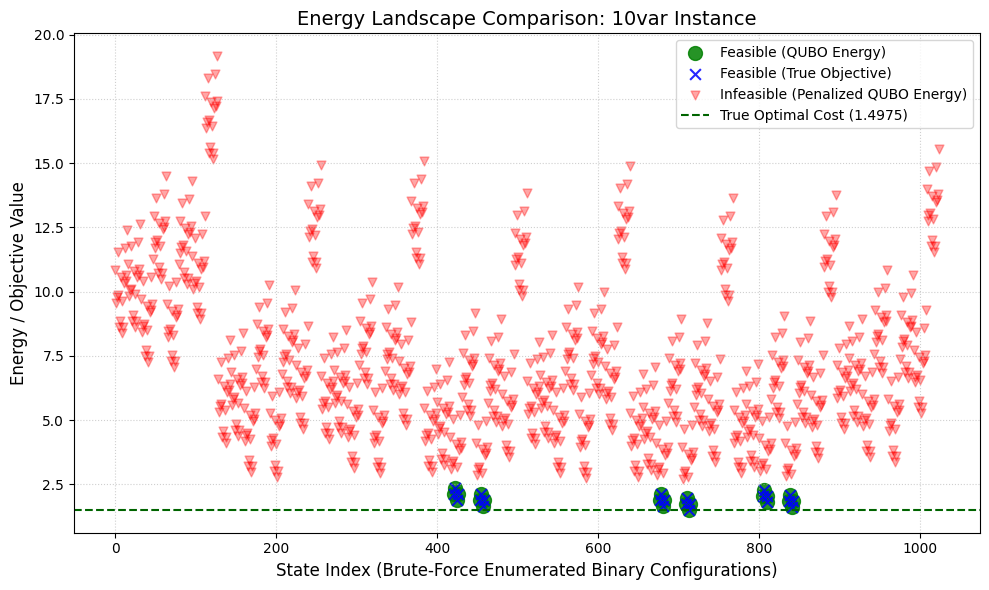

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from model.validate_qubo import enumerate_instance

# Let's plot the energy landscape for the main 10-variable instance ("10var")
instance_name = "10var"
data = enumerate_instance(instance_name)

# Extract details
obj = data["obj"]
feas = data["feas"]
A = data["cfg"]["A"]
# Total QUBO energy = objective-only energy + A * penalty energy
qubo_energy = data["Eo"] + A * data["Ep"]

# Set up the visualization
plt.figure(figsize=(10, 6))

# Plot feasible states
feasible_indices = np.where(feas)[0]
infeasible_indices = np.where(~feas)[0]

plt.scatter(feasible_indices, qubo_energy[feasible_indices], color='green', marker='o', s=100, label='Feasible (QUBO Energy)', alpha=0.85)
plt.scatter(feasible_indices, obj[feasible_indices], color='blue', marker='x', s=60, label='Feasible (True Objective)', alpha=0.85)

# Plot infeasible states (showing they are penalized way above)
plt.scatter(infeasible_indices, qubo_energy[infeasible_indices], color='red', marker='v', s=40, label='Infeasible (Penalized QUBO Energy)', alpha=0.35)

plt.axhline(y=obj[feas].min(), color='darkgreen', linestyle='--', label=f'True Optimal Cost ({obj[feas].min():.4f})')

plt.title(f'Energy Landscape Comparison: {instance_name} Instance', fontsize=14)
plt.xlabel('State Index (Brute-Force Enumerated Binary Configurations)', fontsize=12)
plt.ylabel('Energy / Objective Value', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


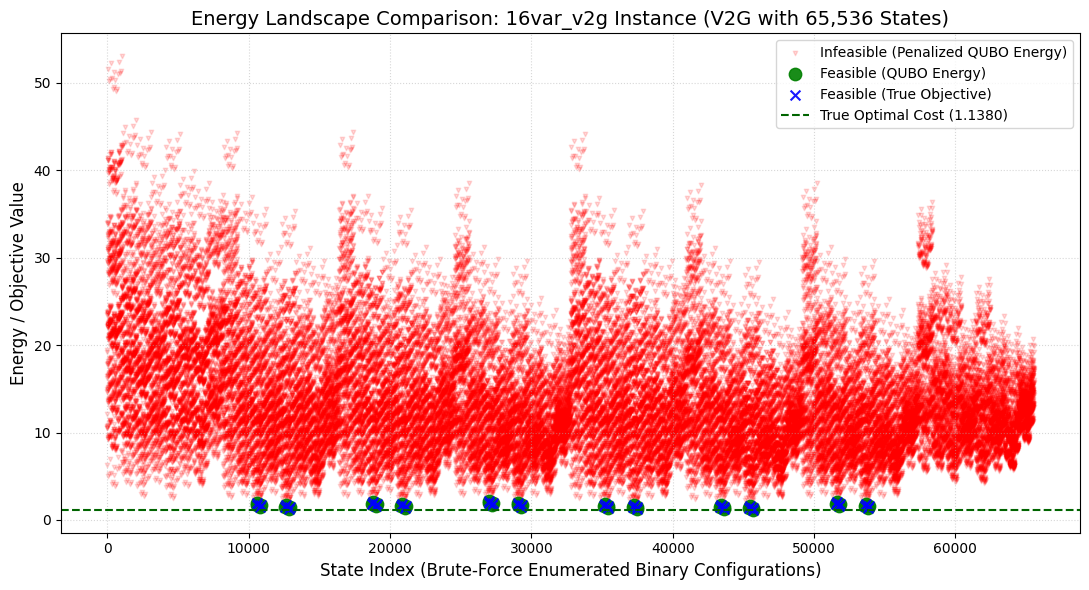

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from model.validate_qubo import enumerate_instance

# Explore the 16var_v2g instance energy landscape
instance_name = "16var_v2g"
data = enumerate_instance(instance_name)

# Extract details
obj = data["obj"]
feas = data["feas"]
A = data["cfg"]["A"]
# Total QUBO energy = objective-only energy + A * penalty energy
qubo_energy = data["Eo"] + A * data["Ep"]

# Set up the visualization
plt.figure(figsize=(11, 6))

# Plot feasible states
feasible_indices = np.where(feas)[0]
infeasible_indices = np.where(~feas)[0]

# Use smaller size or alpha for infeasible states due to the size (65,536 states)
plt.scatter(infeasible_indices, qubo_energy[infeasible_indices], color='red', marker='v', s=10, label='Infeasible (Penalized QUBO Energy)', alpha=0.15)
plt.scatter(feasible_indices, qubo_energy[feasible_indices], color='green', marker='o', s=80, label='Feasible (QUBO Energy)', alpha=0.9)
plt.scatter(feasible_indices, obj[feasible_indices], color='blue', marker='x', s=50, label='Feasible (True Objective)', alpha=0.9)

plt.axhline(y=obj[feas].min(), color='darkgreen', linestyle='--', label=f'True Optimal Cost ({obj[feas].min():.4f})')

plt.title(f'Energy Landscape Comparison: {instance_name} Instance (V2G with 65,536 States)', fontsize=14)
plt.xlabel('State Index (Brute-Force Enumerated Binary Configurations)', fontsize=12)
plt.ylabel('Energy / Objective Value', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from model.variables import INSTANCE_ORDER
from model.validate_qubo import enumerate_instance, check_penalty

rows = []
for name in INSTANCE_ORDER:
    data = enumerate_instance(name)
    A = data["cfg"]["A"]
    passed, d = check_penalty(data, A)

    rows.append({
        "Instance Name": name,
        "Variables (n)": data["n"],
        "Total States (2^n)": len(data["feas"]),
        "Feasible States": d["n_feasible"],
        "Optimal Cost (True Obj)": d["true_opt"],
        "Smallest Passing Penalty A": d["A"],
        "Gap to Infeasible State": d["gap_to_best_infeasible"]
    })

summary_df = pd.DataFrame(rows)
display(summary_df)

,Instance Name,Variables (n),Total States (2^n),Feasible States,Optimal Cost (True Obj),Smallest Passing Penalty A,Gap to Infeasible State
0,4var,4,16,4,1.583639,1.5,0.928571
1,8var,8,256,8,1.434987,1.5,1.192308
2,10var,10,1024,24,1.497484,1.5,1.192308
3,11var_slack,11,2048,16,1.497484,1.5,1.192308
4,16var_v2g,16,65536,48,1.138028,1.5,1.170619


In [ ]:
import dimod
from model.variables import get_config, build_index_map, describe
from model.qubo import build_qubo, to_dimod_bqm, decode

# Get configuration and build QUBO
cfg = get_config("11var_slack")
Q, offset, idx = build_qubo(cfg)

# Convert to dimod Binary Quadratic Model
bqm = to_dimod_bqm(Q, offset)

# Initialize and run Simulated Annealing Sampler
sampler = dimod.SimulatedAnnealingSampler()
response = sampler.sample(bqm, num_reads=100)

# Display the best sample and decode it
best_sample = response.first.sample
best_energy = response.first.energy
bitstring = "".join(str(best_sample[i]) for i in range(len(best_sample)))

print(f"Best Energy found by Simulated Annealing: {best_energy:.6f}")
print(f"Feasible according to model: {response.first.is_feasible if hasattr(response.first, 'is_feasible') else 'N/A'}")
print("\nDecoded Schedule:")
print(describe(bitstring, idx))

Best Energy found by Simulated Annealing: 1.497484
Feasible according to model: N/A

Decoded Schedule:
EV1: charges in slots 0, 2; depot A
EV2: charges in slots 0; depot B


In [ ]:
import dimod
from model.variables import get_config, describe
from model.qubo import build_qubo, to_dimod_bqm

# Configure the 16var_v2g instance
cfg = get_config("16var_v2g")
Q, offset, idx = build_qubo(cfg)

# Convert to a Binary Quadratic Model
bqm = to_dimod_bqm(Q, offset)

# Run Simulated Annealing
sampler = dimod.SimulatedAnnealingSampler()
response = sampler.sample(bqm, num_reads=200)

# Retrieve and print results
best_sample = response.first.sample
best_energy = response.first.energy
bitstring = "".join(str(best_sample[i]) for i in range(len(best_sample)))

print(f"Best Energy found by Simulated Annealing: {best_energy:.6f}")
print("\nDecoded V2G Optimal Schedule:")
print(describe(bitstring, idx))

Best Energy found by Simulated Annealing: 1.138028

Decoded V2G Optimal Schedule:
EV1: charges in slots 0, 2; discharges in slots 1; depot A
EV2: charges in slots 0; discharges in slots none; depot B


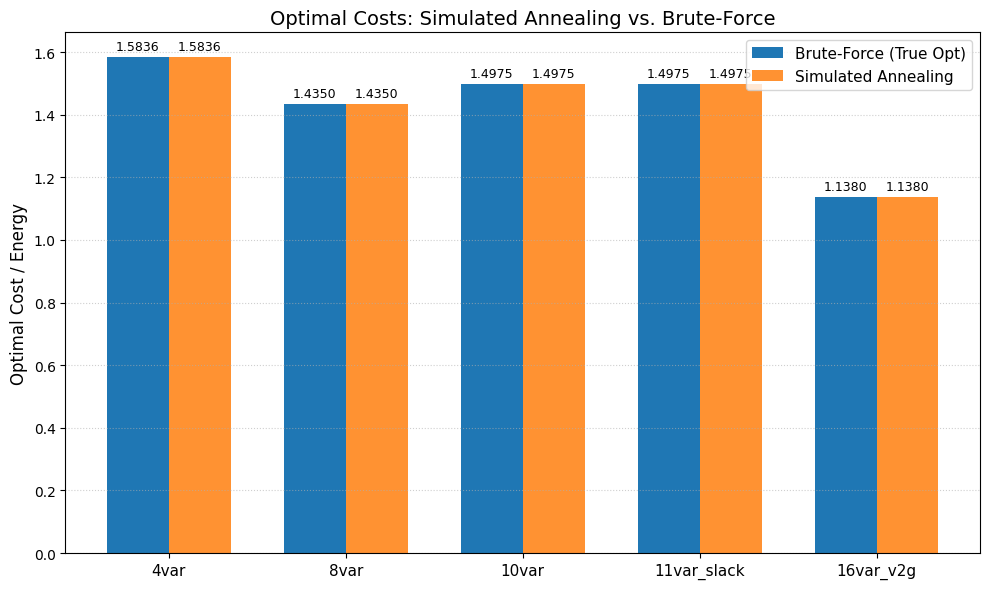

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import dimod
from model.variables import INSTANCE_ORDER, get_config
from model.qubo import build_qubo, to_dimod_bqm
from model.validate_qubo import enumerate_instance

instances = INSTANCE_ORDER
bf_costs = []
sa_costs = []

for name in instances:
    # Get Brute-Force Optimal Cost
    data = enumerate_instance(name)
    true_opt = data["obj"][data["feas"]].min()
    bf_costs.append(true_opt)

    # Run Simulated Annealing
    cfg = get_config(name)
    Q, offset, idx = build_qubo(cfg)
    bqm = to_dimod_bqm(Q, offset)
    sampler = dimod.SimulatedAnnealingSampler()
    response = sampler.sample(bqm, num_reads=100)

    # Best energy found by Simulated Annealing
    sa_costs.append(response.first.energy)

# Plotting the side-by-side bar chart
x = np.arange(len(instances))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, bf_costs, width, label='Brute-Force (True Opt)', color='#1f77b4')
rects2 = ax.bar(x + width/2, sa_costs, width, label='Simulated Annealing', color='#ff7f0e', alpha=0.85)

ax.set_ylabel('Optimal Cost / Energy', fontsize=12)
ax.set_title('Optimal Costs: Simulated Annealing vs. Brute-Force', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(instances, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle=':', alpha=0.6)

# Attach value labels on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import dimod
from model.variables import INSTANCE_ORDER, get_config
from model.qubo import build_qubo, to_dimod_bqm
from model.validate_qubo import enumerate_instance

trials = 100
results = []

for name in INSTANCE_ORDER:
    # Get true ground state energy from brute-force
    data = enumerate_instance(name)
    true_opt = float(data["obj"][data["feas"]].min())

    # Get config and build BQM
    cfg = get_config(name)
    Q, offset, idx = build_qubo(cfg)
    bqm = to_dimod_bqm(Q, offset)

    # Run 100 independent trials
    sampler = dimod.SimulatedAnnealingSampler()
    success_count = 0

    for _ in range(trials):
        response = sampler.sample(bqm, num_reads=10) # 10 reads per run to test efficiency
        best_energy = response.first.energy
        # If the best energy matches the global minimum within a small tolerance
        if abs(best_energy - true_opt) < 1e-6:
            success_count += 1

    success_probability = (success_count / trials) * 100
    results.append({
        "Instance Name": name,
        "Variables (n)": len(idx),
        "Optimal Energy": true_opt,
        "Successful Runs (out of 100)": success_count,
        "Success Probability (%)": f"{success_probability:.1f}%"
    })

prob_df = pd.DataFrame(results)
display(prob_df)

,Instance Name,Variables (n),Optimal Energy,Successful Runs (out of 100),Success Probability (%)
0,4var,4,1.583639,99,99.0%
1,8var,8,1.434987,97,97.0%
2,10var,10,1.497484,88,88.0%
3,11var_slack,11,1.497484,91,91.0%
4,16var_v2g,16,1.138028,74,74.0%


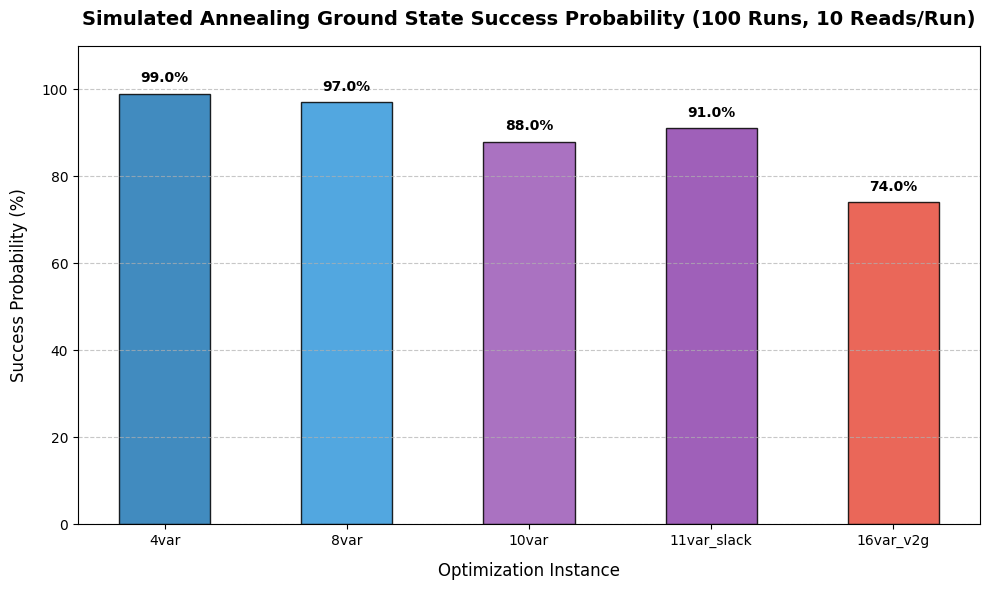

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract names and success probabilities from the results list
instance_names = [res["Instance Name"] for res in results]
# Extract percentage values as floats
probabilities = [float(res["Success Probability (%)"].replace('%', '')) for res in results]

plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#3498db', '#9b59b6', '#8e44ad', '#e74c3c']

bars = plt.bar(instance_names, probabilities, color=colors, width=0.5, edgecolor='black', alpha=0.85)

# Add labels and formatting
plt.title('Simulated Annealing Ground State Success Probability (100 Runs, 10 Reads/Run)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Optimization Instance', fontsize=12, labelpad=10)
plt.ylabel('Success Probability (%)', fontsize=12, labelpad=10)
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display data values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 2, f'{yval:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

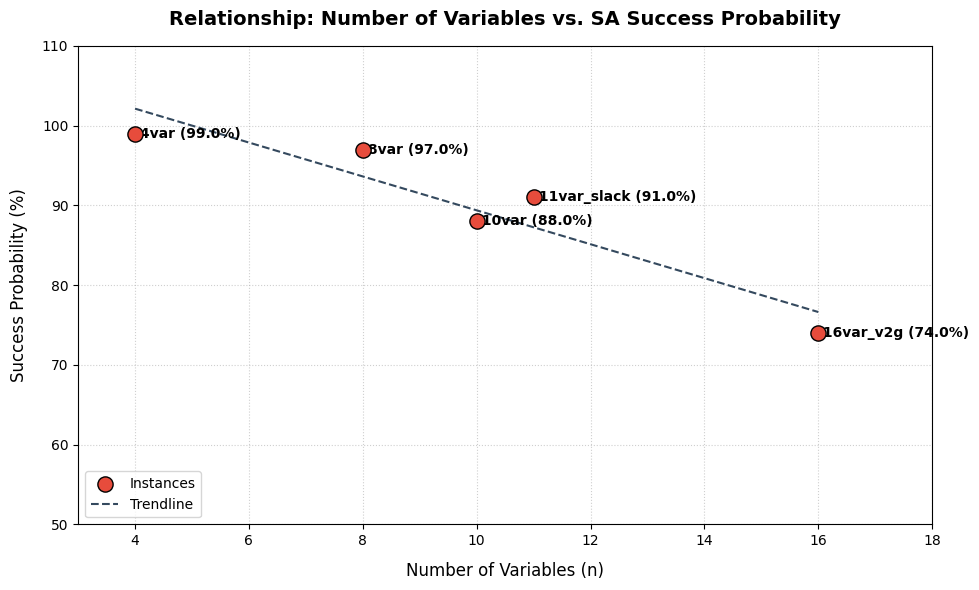

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract variables count and success probabilities from the results list
num_vars = [res["Variables (n)"] for res in results]
probabilities = [float(res["Success Probability (%)"].replace('%', '')) for res in results]
instance_names = [res["Instance Name"] for res in results]

plt.figure(figsize=(10, 6))

# Plot the data points
plt.scatter(num_vars, probabilities, color='#e74c3c', s=120, edgecolor='black', zorder=5, label='Instances')

# Add labels to the points
for i, name in enumerate(instance_names):
    plt.annotate(f" {name} ({probabilities[i]}%)", (num_vars[i], probabilities[i]), fontsize=10, fontweight='bold', va='center', ha='left')

# Calculate and plot a trendline
z = np.polyfit(num_vars, probabilities, 1)
p = np.poly1d(z)
plt.plot(np.unique(num_vars), p(np.unique(num_vars)), color='#34495e', linestyle='--', linewidth=1.5, label='Trendline')

# Formatting the plot
plt.title('Relationship: Number of Variables vs. SA Success Probability', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Variables (n)', fontsize=12, labelpad=10)
plt.ylabel('Success Probability (%)', fontsize=12, labelpad=10)
plt.xlim(min(num_vars) - 1, max(num_vars) + 2)
plt.ylim(50, 110)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

In [ ]:
!pip install dimod

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 20.9 MB/s eta 0:00:00


In [ ]:
"""constraints.py - every constraint is a separate function returning a unit-weight Poly
that is exactly 0 when the constraint holds and >= 1 when violated.
Switch them on/off with the `enabled` list in build_constraint_poly (handy for debugging).
"""
from model.poly import Poly, add_linear, add_product, add_square
from model.variables import build_index_map, headroom, slack_sizes


def charge_count(cfg, idx):
    """Each EV charges exactly k_i slots (net of V2G):  (sum_t x - sum_t g - k_i)^2."""
    poly = Poly(len(idx))
    for i in range(cfg["n_ev"]):
        terms = {idx[("x", i, t)]: 1.0 for t in range(cfg["n_slots"])}
        if cfg["v2g"]:
            terms.update({idx[("g", i, t)]: -1.0 for t in range(cfg["n_slots"])})
        add_square(poly, terms, -cfg["k"][i])
    return poly


def one_depot(cfg, idx):
    """Each EV at exactly one depot:  (sum_d a - 1)^2."""
    poly = Poly(len(idx))
    for i in range(cfg["n_ev"]):
        add_square(poly, {idx[("a", i, d)]: 1.0 for d in range(cfg["n_depots"])}, -1.0)
    return poly


def trip_blocks(cfg, idx):
    """x[i,t] = 0 (and g[i,t] = 0) in slots where the EV is on a trip: penalty x (since x^2 = x)."""
    poly = Poly(len(idx))
    for i, slots in cfg["blocked"].items():
        for t in slots:
            add_linear(poly, idx[("x", i, t)], 1.0)
            if cfg["v2g"]:
                add_linear(poly, idx[("g", i, t)], 1.0)
    return poly


def no_simultaneous(cfg, idx):
    """No charge + discharge in the same slot: x[i,t]*g[i,t] (V2G only)."""
    poly = Poly(len(idx))
    if cfg["v2g"]:
        for i in range(cfg["n_ev"]):
            for t in range(cfg["n_slots"]):
                add_product(poly, idx[("x", i, t)], idx[("g", i, t)], 1.0)
    return poly


def transformer(cfg, idx):
    """L_t + p*net_t <= C  turned into an equality with unary slack bits:
        (sum_i x - sum_i g + sum_m s[t,m] - H_t)^2,   H_t = floor((C - L_t)/p).
    Slots where the limit can never bind get no slack and no penalty."""
    poly = Poly(len(idx))
    for t, S in slack_sizes(cfg).items():
        terms = {idx[("x", i, t)]: 1.0 for i in range(cfg["n_ev"])}
        if cfg["v2g"]:
            terms.update({idx[("g", i, t)]: -1.0 for i in range(cfg["n_ev"])})
        terms.update({idx[("s", t, m)]: 1.0 for m in range(S)})
        add_square(poly, terms, -headroom(cfg, t))
    return poly


CONSTRAINTS = {
    "charge_count": charge_count,
    "one_depot": one_depot,
    "trip_blocks": trip_blocks,
    "no_simultaneous": no_simultaneous,
    "transformer": transformer,
}


def build_constraint_poly(cfg, idx=None, enabled=None):
    """Sum of the enabled constraint penalties (unit weight each). Multiply by A in qubo.py."""
    idx = idx or build_index_map(cfg)
    poly = Poly(len(idx))
    for name in (enabled or CONSTRAINTS):
        poly.add(CONSTRAINTS[name](cfg, idx))
    return poly


In [ ]:
"""objective.py - fleet cost + grid peak penalty + depot cost - V2G revenue.

Every term is divided by its maximum possible value, so each lies in [0, 1] (V2G in [-1, 0])
and no term swamps the others. Relative importance is set by config["weights"].

    energy : sum_{i,t} price_t * p*dt * x[i,t]
    peak   : sum_t (L_t + p*(sum_i x[i,t] - sum_i g[i,t]))^2      (quadratic -> fits a QUBO)
    depot  : sum_{i,d} cost[i,d] * a[i,d]
    v2g    : - sum_{i,t} revenue_t * p*dt * g[i,t]                (V2G instances only)
"""
from model.poly import Poly, add_linear, add_square
from model.variables import build_index_map, as_bits


def normalizers(cfg):
    p, dt, n_ev, T = cfg["p"], cfg["dt"], cfg["n_ev"], cfg["n_slots"]
    e = p * dt
    energy_max = sum(cfg["price"][t] * e * n_ev for t in range(T))
    peak_max = 0.0
    for t in range(T):
        L = cfg["base_load"][t]
        cands = [(L + p * n_ev) ** 2]
        if cfg["v2g"]:
            cands.append((L - p * n_ev) ** 2)
        peak_max += max(cands)
    depot_max = sum(max(row) for row in cfg["depot_cost"])
    v2g_max = sum(cfg["v2g_revenue"][t] * e * n_ev for t in range(T)) if cfg["v2g"] else 1.0
    return dict(energy=energy_max or 1.0, peak=peak_max or 1.0,
                depot=depot_max or 1.0, v2g=v2g_max or 1.0)


def build_objective(cfg, idx=None):
    """Return a Poly (Q, offset) for the objective."""
    idx = idx or build_index_map(cfg)
    poly = Poly(len(idx))
    N, W = normalizers(cfg), cfg["weights"]
    e = cfg["p"] * cfg["dt"]
    for i in range(cfg["n_ev"]):
        for t in range(cfg["n_slots"]):
            add_linear(poly, idx[("x", i, t)], cfg["price"][t] * e, W["energy"] / N["energy"])
            if cfg["v2g"]:
                add_linear(poly, idx[("g", i, t)], -cfg["v2g_revenue"][t] * e, W["v2g"] / N["v2g"])
        for d in range(cfg["n_depots"]):
            add_linear(poly, idx[("a", i, d)], cfg["depot_cost"][i][d], W["depot"] / N["depot"])
    for t in range(cfg["n_slots"]):
        terms = {idx[("x", i, t)]: cfg["p"] for i in range(cfg["n_ev"])}
        if cfg["v2g"]:
            terms.update({idx[("g", i, t)]: -cfg["p"] for i in range(cfg["n_ev"])})
        add_square(poly, terms, cfg["base_load"][t], W["peak"] / N["peak"])
    return poly


def objective_terms(bits, cfg, idx=None):
    """Direct evaluation from the problem definition (NOT through Q). Used for validation."""
    idx = idx or build_index_map(cfg)
    b = as_bits(bits)
    N, W = normalizers(cfg), cfg["weights"]
    e = cfg["p"] * cfg["dt"]
    energy = depot = v2g = peak = 0.0
    for i in range(cfg["n_ev"]):
        for t in range(cfg["n_slots"]):
            energy += cfg["price"][t] * e * b[idx[("x", i, t)]]
            if cfg["v2g"]:
                v2g -= cfg["v2g_revenue"][t] * e * b[idx[("g", i, t)]]
        for d in range(cfg["n_depots"]):
            depot += cfg["depot_cost"][i][d] * b[idx[("a", i, d)]]
    for t in range(cfg["n_slots"]):
        net = sum(b[idx[("x", i, t)]] for i in range(cfg["n_ev"]))
        if cfg["v2g"]:
            net -= sum(b[idx[("g", i, t)]] for i in range(cfg["n_ev"]))
        peak += (cfg["base_load"][t] + cfg["p"] * net) ** 2
    return dict(energy=W["energy"] * energy / N["energy"],
                peak=W["peak"] * peak / N["peak"],
                depot=W["depot"] * depot / N["depot"],
                v2g=W["v2g"] * v2g / N["v2g"])


def objective_value(bits, cfg, idx=None):
    return float(sum(objective_terms(bits, cfg, idx).values()))


In [ ]:
"""poly.py - tiny helper: a QUBO polynomial  sum_i Q_ii x_i + sum_{i<j} Q_ij x_i x_j + offset.

Uses x^2 = x, so linear terms live on the diagonal. Q is stored upper-triangular,
so x^T Q x + offset is the exact energy.
"""
import numpy as np


class Poly:
    def __init__(self, n):
        self.n = n
        self.Q = np.zeros((n, n))
        self.offset = 0.0

    def add(self, other, weight=1.0):
        self.Q += weight * other.Q
        self.offset += weight * other.offset
        return self


def add_linear(poly, i, coef, weight=1.0):
    poly.Q[i, i] += weight * coef


def add_product(poly, i, j, coef, weight=1.0):
    if i == j:
        poly.Q[i, i] += weight * coef        # x*x = x
    else:
        lo, hi = (i, j) if i < j else (j, i)
        poly.Q[lo, hi] += weight * coef


def add_square(poly, terms, const, weight=1.0):
    """Add weight * (sum_i c_i x_i + const)^2   (indices in `terms` must be distinct).

    Expansion with x^2 = x:
        sum_i (c_i^2 + 2 c_i const) x_i  +  2 sum_{i<j} c_i c_j x_i x_j  +  const^2
    e.g. (sum x - k)^2 = sum x + 2 sum_{i<j} x_i x_j - 2k sum x + k^2
    """
    items = list(terms.items())
    poly.offset += weight * const ** 2
    for a, (i, ci) in enumerate(items):
        poly.Q[i, i] += weight * (ci * ci + 2.0 * ci * const)
        for j, cj in items[a + 1:]:
            add_product(poly, i, j, 2.0 * ci * cj, weight)


In [ ]:
"""qubo.py - FROZEN INTERFACE for Person 2.

    build_qubo(config)             -> Q, offset, index_map
    decode(bitstring, index_map)   -> schedule
    is_feasible(bitstring, config) -> bool

Energy of a bitstring x is   x^T Q x + offset   (Q upper-triangular, linear terms on the diagonal).
    QUBO = objective + A * sum(constraint penalties)
"""
import numpy as np

from model.variables import (build_index_map, as_bits, decode_bits, describe,
                             headroom, slack_sizes, soc_trace)
from model.objective import build_objective
from model.constraints import build_constraint_poly


def build_parts(config, enabled=None):
    """(objective Poly, unit-weight constraint Poly, index_map) - used by the penalty sweep."""
    idx = build_index_map(config)
    return build_objective(config, idx), build_constraint_poly(config, idx, enabled), idx


def build_qubo(config, penalty=None, enabled=None):
    """Optional kwargs (penalty, enabled) are for debugging; the frozen call is build_qubo(config)."""
    A = config["A"] if penalty is None else penalty
    Po, Pc, idx = build_parts(config, enabled)
    Q = Po.Q + A * Pc.Q
    offset = Po.offset + A * Pc.offset
    return Q, offset, idx


def decode(bitstring, index_map):
    return decode_bits(bitstring, index_map)


def qubo_energy(bitstring, Q, offset):
    x = as_bits(bitstring)
    return float(x @ Q @ x + offset)


def is_feasible(bitstring, config, idx=None):
    """Direct check of the ORIGINAL constraints (does not use Q)."""
    idx = idx or build_index_map(config)
    b = as_bits(bitstring)
    n_ev, T, D, v2g = config["n_ev"], config["n_slots"], config["n_depots"], config["v2g"]
    x = lambda i, t: b[idx[("x", i, t)]]
    g = lambda i, t: b[idx[("g", i, t)]] if v2g else 0

    for i in range(n_ev):
        if sum(x(i, t) - g(i, t) for t in range(T)) != config["k"][i]:
            return False                                   # charge count (net)
        if sum(b[idx[("a", i, d)]] for d in range(D)) != 1:
            return False                                   # exactly one depot
        for t in config["blocked"].get(i, []):
            if x(i, t) or g(i, t):
                return False                               # on a trip
        for t in range(T):
            if x(i, t) and g(i, t):
                return False                               # charge + discharge together
    sizes = slack_sizes(config)
    for t in range(T):
        net = sum(x(i, t) - g(i, t) for i in range(n_ev))
        if config["base_load"][t] + config["p"] * net > config["C"] + 1e-9:
            return False                                   # transformer limit
        if t in sizes:                                     # slack bits must encode the headroom
            if sum(b[idx[("s", t, m)]] for m in range(sizes[t])) != headroom(config, t) - net:
                return False
    for row in soc_trace(b, config, idx):                  # battery bounds
        if min(row) < config["soc_min"] - 1e-9 or max(row) > config["capacity"] + 1e-9:
            return False
    return True


def to_dimod_bqm(Q, offset=0.0):
    import dimod
    qd = {(i, j): float(Q[i, j]) for i in range(Q.shape[0])
          for j in range(i, Q.shape[1]) if abs(Q[i, j]) > 0}
    return dimod.BinaryQuadraticModel.from_qubo(qd, offset)


In [ ]:
"""validate_qubo.py - the most important file.

For every bitstring in {0,1}^n it computes
    obj   : the ORIGINAL objective, evaluated directly from the problem definition
    feas  : feasibility, checked directly from the problem definition
    E(A)  : the QUBO energy  x^T Q x + offset
and asserts the QUBO is a faithful model:
    1. objective polynomial == direct objective on ALL states   (expansion is exact)
    2. penalty is zero  <=>  state is feasible
    3. QUBO minimum == true optimum (lowest-cost feasible state)
    4. every QUBO ground state is feasible and optimal
    5. no infeasible state has energy below the optimum
    6. dimod.ExactSolver agrees (if dimod is installed)

Run:  python -m model.validate_qubo              (all instances)
      python -m model.validate_qubo 10var        (one instance)
      python -m model.validate_qubo --export     (write hand-off package to handoff/)
"""
import itertools
import json
import os
import sys
from functools import lru_cache

import numpy as np

from model.variables import INSTANCE_ORDER, get_config, describe, to_str
from model.objective import objective_value
from model.qubo import build_parts, is_feasible, to_dimod_bqm

TOL = 1e-9
A_GRID = [0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1, 1.5, 2, 3, 5, 10, 20, 50]


def all_states(n):
    """All 2^n bitstrings via itertools.product -> (2^n, n) float array."""
    return np.array(list(itertools.product([0, 1], repeat=n)), dtype=float)


def energies(X, Q, offset):
    return np.einsum("si,ij,sj->s", X, Q, X) + offset


@lru_cache(maxsize=None)
def enumerate_instance(name):
    """Brute-force everything once per instance (cached)."""
    cfg = get_config(name)
    Po, Pc, idx = build_parts(cfg)
    n = len(idx)
    X = all_states(n)
    obj = np.array([objective_value(x, cfg, idx) for x in X])
    feas = np.array([is_feasible(x, cfg, idx=idx) for x in X])
    return dict(
        name=name, cfg=cfg, idx=idx, n=n, X=X, obj=obj, feas=feas,
        Eo=energies(X, Po.Q, Po.offset),     # objective-only energies
        Ep=energies(X, Pc.Q, Pc.offset),     # unit-weight penalty energies
        Po=Po, Pc=Pc,
    )


def check_penalty(data, A):
    """Run checks 1-5 for penalty A. Returns (passed, details dict)."""
    obj, feas, Eo, Ep = data["obj"], data["feas"], data["Eo"], data["Ep"]
    E = Eo + A * Ep
    true_opt = obj[feas].min()
    opt_mask = feas & (np.abs(obj - true_opt) < 1e-7)
    e_min = E.min()
    ground = E <= e_min + 1e-7

    c_expansion = bool(np.allclose(Eo, obj, atol=1e-7))
    c_pen_zero_iff_feas = bool(np.all(np.abs(Ep[feas]) < 1e-7) and np.all(Ep[~feas] > 0.5)) \
        if (~feas).any() else bool(np.all(np.abs(Ep[feas]) < 1e-7))
    c_min = bool(abs(e_min - true_opt) < 1e-7)
    c_ground = bool(np.all(opt_mask[ground]))
    gap = float(E[~feas].min() - true_opt) if (~feas).any() else float("inf")
    c_gap = gap > 1e-7
    passed = c_expansion and c_pen_zero_iff_feas and c_min and c_ground and c_gap
    return passed, dict(
        A=A, true_opt=float(true_opt), qubo_min=float(e_min), gap_to_best_infeasible=gap,
        expansion_exact=c_expansion, penalty_zero_iff_feasible=c_pen_zero_iff_feas,
        min_matches=c_min, ground_states_optimal=c_ground, no_infeasible_below=c_gap,
        n_ground=int(ground.sum()), n_feasible=int(feas.sum()), n_states=len(feas),
    )


def sweep_penalty(name, grid=A_GRID):
    """Returns (results, A_min): A_min = smallest grid value from which ALL larger values pass."""
    data = enumerate_instance(name)
    results = [(A, check_penalty(data, A)[0]) for A in grid]
    A_min = None
    for A, ok in reversed(results):
        if ok:
            A_min = A
        else:
            break
    return results, A_min


def dimod_crosscheck(name, A=None):
    """Compare against dimod.ExactSolver. Returns True / False / None (dimod missing)."""
    try:
        import dimod
    except ImportError:
        return None
    data = enumerate_instance(name)
    A = data["cfg"]["A"] if A is None else A
    Q = data["Po"].Q + A * data["Pc"].Q
    off = data["Po"].offset + A * data["Pc"].offset
    bqm = to_dimod_bqm(Q, off)
    ss = dimod.ExactSolver().sample(bqm)
    e_dimod = float(ss.first.energy)
    e_mine = float((data["Eo"] + A * data["Ep"]).min())
    ok_energy = abs(e_dimod - e_mine) < 1e-7
    # same set of ground states?
    ground_dimod = set()
    for samp, en in ss.data(["sample", "energy"]):
        if en <= e_dimod + 1e-7:
            ground_dimod.add(tuple(int(samp[j]) for j in range(data["n"])))
    E = data["Eo"] + A * data["Ep"]
    ground_mine = {tuple(int(v) for v in data["X"][s]) for s in np.where(E <= e_mine + 1e-7)[0]}
    return bool(ok_energy and ground_dimod == ground_mine)


def validate_instance(name, verbose=True):
    data = enumerate_instance(name)
    A = data["cfg"]["A"]
    passed, d = check_penalty(data, A)
    results, A_min = sweep_penalty(name)
    dm = dimod_crosscheck(name)
    if verbose:
        print(f"\n=== {name}: {data['n']} variables, {d['n_states']} states, "
              f"{d['n_feasible']} feasible ===")
        print(f"true optimum (brute force)   : {d['true_opt']:.6f}")
        print(f"QUBO minimum at A={A:<6}      : {d['qubo_min']:.6f}   "
              f"{'PASS' if passed else 'FAIL'}")
        print(f"gap to best infeasible state : {d['gap_to_best_infeasible']:.4f}")
        print(f"smallest passing A (grid)    : {A_min}")
        print("sweep                        : " +
              " ".join(f"{a}:{'ok' if ok else 'X'}" for a, ok in results))
        print(f"dimod.ExactSolver cross-check: "
              f"{'skipped (dimod not installed)' if dm is None else ('PASS' if dm else 'FAIL')}")
        for key in ("expansion_exact", "penalty_zero_iff_feasible", "min_matches",
                    "ground_states_optimal", "no_infeasible_below"):
            print(f"  [{'x' if d[key] else ' '}] {key}")
        best = np.where(data["feas"] & (np.abs(data["obj"] - d["true_opt"]) < 1e-7))[0]
        for s in best[:3]:
            print(f"optimal state {to_str(data['X'][s])}:")
            print("   " + describe(data["X"][s], data["idx"]).replace("\n", "\n   "))
    return dict(name=name, passed=passed and dm is not False, A=A, A_min=A_min, details=d)


def export_handoff(outdir="handoff"):
    """Ground truth JSON + Q heatmap per instance, for Person 2."""
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    os.makedirs(outdir, exist_ok=True)
    summary = {}
    for name in INSTANCE_ORDER:
        data = enumerate_instance(name)
        A = data["cfg"]["A"]
        passed, d = check_penalty(data, A)
        _, A_min = sweep_penalty(name)
        E = data["Eo"] + A * data["Ep"]
        best = np.where(data["feas"] & (np.abs(data["obj"] - d["true_opt"]) < 1e-7))[0]
        summary[name] = dict(
            n_variables=data["n"], penalty_A=A, smallest_passing_A=A_min,
            optimum_energy=d["true_opt"], validated=passed,
            optimal_bitstrings=[to_str(data["X"][s]) for s in best],
            decoded=[describe(data["X"][s], data["idx"]) for s in best],
            variable_order=[list(map(str, k)) for k in data["idx"]],
        )
        Q = data["Po"].Q + A * data["Pc"].Q
        S = Q + Q.T - np.diag(np.diag(Q))          # symmetric view for plotting
        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(S, cmap="coolwarm", vmin=-abs(S).max(), vmax=abs(S).max())
        labels = ["".join(map(str, k)) for k in data["idx"]]
        ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=90, fontsize=6)
        ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=6)
        ax.set_title(f"Q matrix - {name} (A={A})")
        fig.colorbar(im); fig.tight_layout()
        fig.savefig(os.path.join(outdir, f"Q_heatmap_{name}.png"), dpi=150)
        plt.close(fig)
    with open(os.path.join(outdir, "ground_truth.json"), "w") as f:
        json.dump(summary, f, indent=2)
    print(f"hand-off written to {outdir}/")


if __name__ == "__main__":
    args = [a for a in sys.argv[1:] if not a.startswith("--")]
    if "--export" in sys.argv:
        export_handoff()
    else:
        names = args or INSTANCE_ORDER
        reports = [validate_instance(n) for n in names]
        print("\nSUMMARY:", {r["name"]: ("PASS" if r["passed"] else "FAIL") for r in reports})
        sys.exit(0 if all(r["passed"] for r in reports) else 1)


In [ ]:
"""variables.py - instance configs, binary-variable index map, SOC, decoding.

Binary variables (all are 0/1):
    ("x", i, t)  EV i charges in slot t
    ("a", i, d)  EV i is assigned to depot d
    ("g", i, t)  EV i discharges to the grid (V2G) in slot t      [v2g instances]
    ("s", t, m)  unary slack bit m for the transformer limit      [slack instances]

SOC is NOT a variable. It is computed from the bits:
    soc[i, t] = soc_start[i] + p*dt * sum_{s<=t} (x[i,s] - g[i,s])
"""
import copy
import math
import numpy as np

# ----------------------------------------------------------------------
# Master data. Each instance takes the first n_ev / n_slots / n_depots
# entries, so every instance is a consistent "sub-problem" of the next.
# ----------------------------------------------------------------------
_MASTER = dict(
    price=[0.12, 0.30, 0.18],          # $/kWh per slot
    base_load=[20.0, 35.0, 25.0],      # kW, non-EV load on the transformer
    v2g_revenue=[0.10, 0.35, 0.20],    # $/kWh paid for discharging
    depot_cost=[[2.0, 3.5],            # $ for EV i to use depot d (trip/route cost)
                [3.0, 1.5]],
)


def _make(name, n_ev, n_slots, n_depots, k, blocked=None, v2g=False,
          C=60.0, slack=False, A=1.5):
    return dict(
        name=name,
        n_ev=n_ev, n_slots=n_slots, n_depots=n_depots,
        p=10.0,                        # charger power (kW)
        dt=1.0,                        # slot length (h) -> 10 kWh per slot
        price=_MASTER["price"][:n_slots],
        base_load=_MASTER["base_load"][:n_slots],
        v2g_revenue=_MASTER["v2g_revenue"][:n_slots],
        depot_cost=[row[:n_depots] for row in _MASTER["depot_cost"][:n_ev]],
        k=k,                           # slots each EV must charge (net of V2G)
        blocked={int(i): list(v) for i, v in (blocked or {}).items()},  # EV on a trip
        C=C,                           # transformer limit (kW)
        capacity=60.0,                 # battery kWh
        soc_start=[30.0] * n_ev,       # kWh
        soc_min=5.0,                   # kWh
        v2g=v2g,
        transformer_slack=slack,
        weights=dict(energy=1.0, peak=1.0, depot=1.0, v2g=1.0),
        A=A,                           # constraint penalty (validated by validate_qubo.py)
    )


CONFIGS = {
    # 1 EV x 2 slots + 1 EV x 2 depots = 4 variables
    "4var":  _make("4var", 1, 2, 2, k=[1]),
    # 2*2 + 2*2 = 8 variables
    "8var":  _make("8var", 2, 2, 2, k=[1, 1], blocked={1: [1]}),
    # 2*3 + 2*2 = 10 variables  <- the main Tier 1+2 instance
    "10var": _make("10var", 2, 3, 2, k=[2, 1], blocked={1: [2]}),
    # same as 10var but tighter transformer (45 kW) -> 1 slack bit in slot 1 = 11 vars
    "11var_slack": _make("11var_slack", 2, 3, 2, k=[2, 1], blocked={1: [2]},
                         C=45.0, slack=True),
    # 10 + g[i,t] (6) = 16 variables. k is NET charging (x - g).
    "16var_v2g": _make("16var_v2g", 2, 3, 2, k=[1, 1], blocked={1: [2]}, v2g=True),
}
INSTANCE_ORDER = ["4var", "8var", "10var", "11var_slack", "16var_v2g"]


def get_config(name="10var"):
    return copy.deepcopy(CONFIGS[name])


# ----------------------------------------------------------------------
# Transformer headroom / slack sizing
# ----------------------------------------------------------------------
def headroom(config, t):
    """Max number of net-charging EVs slot t can take: floor((C - L_t)/p)."""
    return math.floor((config["C"] - config["base_load"][t]) / config["p"] + 1e-9)


def slack_sizes(config):
    """{slot: number of unary slack bits}; only slots where the limit can bind.

    Constraint: (sum_i x - sum_i g + sum_m s - H_t)^2 = 0, where net = sum x - sum g
    ranges in [-off, n_ev] (off = n_ev if V2G else 0), so S_t = H_t + off bits.
    """
    if not config["transformer_slack"]:
        return {}
    off = config["n_ev"] if config["v2g"] else 0
    out = {}
    for t in range(config["n_slots"]):
        H = headroom(config, t)
        if H < 0:
            raise ValueError(f"Slot {t}: base load already exceeds transformer limit")
        if H < config["n_ev"]:
            out[t] = H + off
    return out


# ----------------------------------------------------------------------
# Index map: (type, i, t or d) -> integer 0..n-1
# ----------------------------------------------------------------------
def build_index_map(config):
    idx, n = {}, 0
    for i in range(config["n_ev"]):
        for t in range(config["n_slots"]):
            idx[("x", i, t)] = n; n += 1
    for i in range(config["n_ev"]):
        for d in range(config["n_depots"]):
            idx[("a", i, d)] = n; n += 1
    if config["v2g"]:
        for i in range(config["n_ev"]):
            for t in range(config["n_slots"]):
                idx[("g", i, t)] = n; n += 1
    for t, S in slack_sizes(config).items():
        for m in range(S):
            idx[("s", t, m)] = n; n += 1
    return idx


def as_bits(bitstring):
    """Accept '0101', list, tuple or ndarray -> 1-D int ndarray."""
    if isinstance(bitstring, str):
        return np.array([int(c) for c in bitstring], dtype=int)
    return np.asarray(bitstring).astype(int).ravel()


def to_str(bits):
    return "".join(str(int(b)) for b in as_bits(bits))


def bits_from_dict(config, idx, charge=(), depot=(), discharge=(), slack=()):
    """Helper for hand-picked test bitstrings.
    charge/discharge: iterable of (i, t); depot: iterable of (i, d); slack: (t, m)."""
    b = np.zeros(len(idx), dtype=int)
    for i, t in charge:
        b[idx[("x", i, t)]] = 1
    for i, d in depot:
        b[idx[("a", i, d)]] = 1
    for i, t in discharge:
        b[idx[("g", i, t)]] = 1
    for t, m in slack:
        b[idx[("s", t, m)]] = 1
    return b


# ----------------------------------------------------------------------
# SOC (computed, never a variable)
# ----------------------------------------------------------------------
def soc_trace(bits, config, idx):
    """soc[i][t] = SOC (kWh) of EV i at the END of slot t."""
    bits = as_bits(bits)
    e = config["p"] * config["dt"]
    trace = []
    for i in range(config["n_ev"]):
        soc, row = config["soc_start"][i], []
        for t in range(config["n_slots"]):
            soc += e * bits[idx[("x", i, t)]]
            if config["v2g"]:
                soc -= e * bits[idx[("g", i, t)]]
            row.append(soc)
        trace.append(row)
    return trace


# ----------------------------------------------------------------------
# Decoding
# ----------------------------------------------------------------------
def decode_bits(bitstring, idx):
    """bitstring -> schedule dict {'charge': {i:[t..]}, 'discharge': {i:[t..]}, 'depot': {i:[d..]}}"""
    bits = as_bits(bitstring)
    n_ev = 1 + max(k[1] for k in idx if k[0] in ("x", "a", "g"))
    sched = dict(charge={i: [] for i in range(n_ev)},
                 discharge={i: [] for i in range(n_ev)},
                 depot={i: [] for i in range(n_ev)})
    for key, pos in idx.items():
        if not bits[pos]:
            continue
        kind, a, b = key
        if kind == "x":
            sched["charge"][a].append(b)
        elif kind == "g":
            sched["discharge"][a].append(b)
        elif kind == "a":
            sched["depot"][a].append(b)
    for part in sched.values():
        for v in part.values():
            v.sort()
    return sched


def describe(bitstring, idx):
    """'EV1: charges in slots 0, 2; depot A' (EVs are 1-based, slots 0-based)."""
    sched = decode_bits(bitstring, idx)
    has_g = any(k[0] == "g" for k in idx)
    lines = []
    for i in sorted(sched["charge"]):
        ch = ", ".join(map(str, sched["charge"][i])) or "none"
        dep = "+".join(chr(65 + d) for d in sched["depot"][i]) or "no depot"
        s = f"EV{i + 1}: charges in slots {ch}"
        if has_g:
            s += "; discharges in slots " + (", ".join(map(str, sched["discharge"][i])) or "none")
        lines.append(s + f"; depot {dep}" if dep != "no depot" else s + "; no depot")
    return "\n".join(lines)


if __name__ == "__main__":
    for name in INSTANCE_ORDER:
        cfg = get_config(name)
        idx = build_index_map(cfg)
        print(f"{name}: {len(idx)} binary variables")
    cfg = get_config("10var")
    idx = build_index_map(cfg)
    demo = bits_from_dict(cfg, idx, charge=[(0, 0), (0, 2), (1, 1)], depot=[(0, 0), (1, 1)])
    print(to_str(demo))
    print(describe(demo, idx))
